In [1]:
"""
Work and energy conversion efficiency for a neutrally buoyant sphere
(rho_p = rho_f) executing a Gaussian velocity pulse in quiescent fluid.

Velocity:  U(t) = [L/(sqrt(2*pi)*tau)] * exp(-(t-tau_p)^2/(2*tau^2))

Governing equation (dimensional):

  m_eff*Udot = -(pi*D^2/8)*rho*U*|U|*C_D(Re)
               - 3*pi*mu*D * integral_{-inf}^{t} K(t-t')*Udot(t') dt'
               + F_thrust

  m_eff = (1+C_M)*rho*(pi*D^3/6),  C_M=1/2

Drag: White (1991) / Dorgan & Loth (2007) eq.(3):
  C_D = (24/Re)*[1 + Re/(4*(1+sqrt(Re))) + Re/60]

History kernel: Dorgan & Loth (2007) eq.(5), c1=2.5, c2=0.2 (Re_p <= 853):
  K(xi) = {[4*pi*xi/tau_d]^(1/(2*c1)) + [pi*xi^2*Re^3/(f_H*tau_d^2)]^(1/c1)}^(-c1)
  f_H = (0.75+c2*Re)^3,  tau_d = D^2/nu
  F_hist = -3*pi*mu*D * integral K(xi)*Udot(t-xi) dxi

Time grid:
  dt = tau/200,  window = 10*tau  (universal, for all Gamma).
  Justification: Udot(t-xi) is Gaussian in xi with width tau.
  Beyond xi=10*tau, |Udot| < exp(-50)*U_max/tau ~ machine zero.
  The kernel's long memory beyond 10*tau multiplies a negligible integrand.
  N = 16*200 = 3200, n_win = 10*200 = 2000.  Cost ~ 6.4e6 ops (fast).

Prefactor: 3*pi*mu*D [kg/s] * integral K*Udot*dxi [m/s] = N.
  Stokes limit: K->sqrt(tau_d/(4*pi))*xi^{-1/2}, giving the Landau result
  within sqrt(2) (D&L calibration offset vs pure Basset; see code notes).

Energy conversion efficiency:
  alpha_p = (1/2)*m_p*U_max^2 / W_pos   (particle KE only)
  alpha_e = (1/2)*m_eff*U_max^2 / W_pos (particle + added-mass KE)
"""

import numpy as np

if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz


def energy_efficiency_phase(D, L, tau, c1=2.5, c2=0.2):
    """
    Parameters
    ----------
    D   : sphere diameter [m]  (sets tau_d; does not affect Re_T, Ac, Gamma)
    L   : body length [m]      (sets U_max = L/(sqrt(2*pi)*tau))
    tau : Gaussian pulse width [s]
    c1, c2 : D&L kernel coefficients. Default: 2.5, 0.2 (valid Re_p <= 853).
    """
    tau_p = 5e-3
    rho   = 1000.0
    nu    = 1e-6
    mu    = rho * nu

    C_M   = 0.5
    R     = D / 2.0
    V_sph = (4.0/3.0)*np.pi*R**3
    m_p   = rho * V_sph
    m_eff = (1.0 + C_M)*rho*V_sph

    tau_d    = D**2 / nu
    prefac_B = 3.0*np.pi*mu*D      # [kg/s]

    # ── Time grid: universal dt=tau/200, window=10*tau ─────────────────────
    # Udot is Gaussian with width tau; |Udot(t-xi)| < exp(-50)*scale for xi>10*tau.
    # The long kernel memory beyond 10*tau multiplies a negligible Udot => safe to truncate.
    dt    = tau / 200.0
    t_start = tau_p - 6.0*tau
    t_end   = tau_p + 10.0*tau
    t     = np.arange(t_start, t_end, dt)
    N     = len(t)
    n_win = int(np.ceil(10.0*tau / dt))   # = 2000

    # ── Kinematics ─────────────────────────────────────────────────────────
    U_peak = L / (np.sqrt(2.0*np.pi)*tau)
    U      = U_peak * np.exp(-0.5*((t - tau_p)/tau)**2)
    Udot   = -(t - tau_p)/tau**2 * U
    Re_t   = rho*np.abs(U)*D/mu

    # ── Ac, Ac_corr ────────────────────────────────────────────────────────
    peak_a  = np.abs(Udot).max()
    tau_0   = rho*D**2/(18.0*mu)
    tau_a   = np.sqrt(D/peak_a)
    Ac      = tau_0/tau_a
    Ac_corr = Ac*(1.0 + 0.15*Re_t.max()**0.687)**(-1)

    # ── Quasi-steady drag: White (1991) ────────────────────────────────────
    def C_D_white(Re):
        Re  = np.asarray(Re, dtype=float)
        Res = np.where(Re < 1e-12, 1e-12, Re)
        f   = 1.0 + Res/(4.0*(1.0+np.sqrt(Res))) + Res/60.0
        return (24.0/Res)*f

    F_drag = -(np.pi*D**2/8.0)*rho*U*np.abs(U)*C_D_white(Re_t)

    # ── History force: D&L (2007) eq.(5) ───────────────────────────────────
    def K_full(xi, Re_p):
        f_H   = (0.75 + c2*Re_p)**3
        term1 = (4.0*np.pi*xi/tau_d)**(1.0/(2.0*c1))
        term2 = (np.pi*xi**2*Re_p**3/(f_H*tau_d**2))**(1.0/c1)
        return (term1 + term2)**(-c1)

    # Near-field leading form: K(xi) -> sqrt(tau_d/(4*pi)) * xi^{-1/2} as xi->0
    near_prefac = np.sqrt(tau_d/(4.0*np.pi))

    F_hist = np.zeros(N)
    for i in range(1, N):
        # Near-field: exact integral of xi^{-1/2} leading term over [0, dt]
        xi_mid = 0.5*dt
        Re_mid = Re_t[i-1]
        K_lead = near_prefac * xi_mid**(-0.5)
        K_mid  = K_full(np.array([xi_mid]), np.array([Re_mid]))[0]
        supp   = K_mid/K_lead if K_lead > 0.0 else 0.0
        F_hist[i] += near_prefac * 2.0*np.sqrt(dt) * supp * Udot[i-1]

        # Far-field: trapezoid over [t_{j_lo}, t_{i-1}]
        if i >= 2:
            j_lo = max(0, i-1-n_win)
            j    = np.arange(j_lo, i-1)
            if len(j) > 0:
                xi  = t[i] - t[j]
                K_j = K_full(xi, Re_t[j])
                F_hist[i] += np.trapezoid(K_j*Udot[j], t[j])

    F_hist *= -prefac_B

    # ── Thrust force and work ───────────────────────────────────────────────
    F_inertia = m_eff * Udot
    F_thrust  = F_inertia - F_drag - F_hist

    power     = F_thrust * U
    W_total   = np.trapezoid(power, t)
    W_pos     = np.trapezoid(np.maximum(power, 0.0), t)
    W_neg     = np.trapezoid(np.minimum(power, 0.0), t)
    W_inertia = np.trapezoid(F_inertia*U, t)
    W_drag_w  = np.trapezoid(-F_drag*U,   t)
    W_hist_w  = np.trapezoid(-F_hist*U,   t)

    # ── Efficiency ─────────────────────────────────────────────────────────
    KE_p_max   = (0.5*m_p  *U**2).max()
    KE_eff_max = (0.5*m_eff*U**2).max()
    alpha_p    = KE_p_max   / W_pos * 100.0
    alpha_e    = KE_eff_max / W_pos * 100.0

    return {
        'Re_T'     : Re_t.max(),
        'Gamma'    : nu*tau/D**2,
        'Ac'       : Ac,
        'Ac_corr'  : Ac_corr,
        'alpha_p'  : alpha_p,
        'alpha_e'  : alpha_e,
        'W_total'  : W_total,
        'W_pos'    : W_pos,
        'W_neg'    : W_neg,
        'W_inertia': W_inertia,
        'W_drag_w' : W_drag_w,
        'W_hist_w' : W_hist_w,
    }

In [3]:
"""
Phase-space sampling for kriging of alpha(Re_T, Ac).

Grid: 20x20 log-uniform in Re_T [1e-4, 1e3] x Ac [1e-5, 1e2].

D = 50 um throughout. D does not affect Re_T, Ac, or Gamma.
No Gamma floor needed: energy_efficiency_phase uses dt=tau/200 and
window=10*tau universally. Cost is fixed at ~6.4e6 ops per point.
"""

import numpy as np
import pickle
from itertools import product as iproduct

rho = 1000.0; mu = 1e-3; nu = mu/rho
alpha_Re = rho / (mu*np.sqrt(2.0*np.pi))
alpha_Ac = rho / (18.0*mu*(2.0*np.pi)**0.25*np.e**0.25)
ratio_LD = (alpha_Ac/alpha_Re)**2

D_FIXED = 50e-6

Re_T_grid = np.logspace(-4, 3, 20)
Ac_grid   = np.logspace(-5, 2, 20)

param_list = []
for Re_T, Ac in iproduct(Re_T_grid, Ac_grid):
    tau = alpha_Ac*np.sqrt(ratio_LD)*Re_T*D_FIXED**2/Ac**2
    L   = D_FIXED*ratio_LD*(Re_T/Ac)**2
    if not (np.isfinite(tau) and tau > 0 and np.isfinite(L) and L > 0):
        continue
    if Re_T > 1e3:
        continue
    Gamma = nu*tau/D_FIXED**2
    param_list.append(dict(Re_T=Re_T, Ac=Ac, D=D_FIXED, L=L, tau=tau, Gamma=Gamma))

print(f"Grid points: {len(param_list)}")
print(f"Re_T: {min(p['Re_T'] for p in param_list):.1e} -- {max(p['Re_T'] for p in param_list):.1e}")
print(f"Ac:   {min(p['Ac']   for p in param_list):.1e} -- {max(p['Ac']   for p in param_list):.1e}")
print(f"Gamma:{min(p['Gamma'] for p in param_list):.2e} -- {max(p['Gamma'] for p in param_list):.2e}")

results = []
for i, p in enumerate(param_list):
    try:
        r = energy_efficiency_phase(p['D'], p['L'], p['tau'])
        r.update(p)
        results.append(r)
    except Exception as exc:
        print(f"  FAILED i={i} Re_T={p['Re_T']:.2e} Ac={p['Ac']:.2e}: {exc}")
        continue
    if (i+1) % 20 == 0 or (i+1) == len(param_list):
        print(f"  {i+1}/{len(param_list)}  Re_T={p['Re_T']:.2e}  Ac={p['Ac']:.2e}"
              f"  alpha_p={results[-1]['alpha_p']:.2f}%  Gamma={p['Gamma']:.2e}")

with open('phase_space_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print(f"\nDone. {len(results)} results saved.")

Grid points: 400
Re_T: 1.0e-04 -- 1.0e+03
Ac:   1.0e-05 -- 1.0e+02
Gamma:1.87e-11 -- 1.87e+10
  20/400  Re_T=1.00e-04  Ac=1.00e+02  alpha_p=66.66%  Gamma=1.87e-11
  40/400  Re_T=2.34e-04  Ac=1.00e+02  alpha_p=66.66%  Gamma=4.37e-11
  60/400  Re_T=5.46e-04  Ac=1.00e+02  alpha_p=66.66%  Gamma=1.02e-10
  80/400  Re_T=1.27e-03  Ac=1.00e+02  alpha_p=66.66%  Gamma=2.39e-10
  100/400  Re_T=2.98e-03  Ac=1.00e+02  alpha_p=66.65%  Gamma=5.57e-10
  120/400  Re_T=6.95e-03  Ac=1.00e+02  alpha_p=66.65%  Gamma=1.30e-09
  140/400  Re_T=1.62e-02  Ac=1.00e+02  alpha_p=66.63%  Gamma=3.04e-09
  160/400  Re_T=3.79e-02  Ac=1.00e+02  alpha_p=66.62%  Gamma=7.10e-09
  180/400  Re_T=8.86e-02  Ac=1.00e+02  alpha_p=66.59%  Gamma=1.66e-08
  200/400  Re_T=2.07e-01  Ac=1.00e+02  alpha_p=66.55%  Gamma=3.87e-08
  220/400  Re_T=4.83e-01  Ac=1.00e+02  alpha_p=66.49%  Gamma=9.05e-08
  240/400  Re_T=1.13e+00  Ac=1.00e+02  alpha_p=66.39%  Gamma=2.11e-07
  260/400  Re_T=2.64e+00  Ac=1.00e+02  alpha_p=66.24%  Gamma=4.94e-07


In [5]:
import matplotlib.pyplot as plt

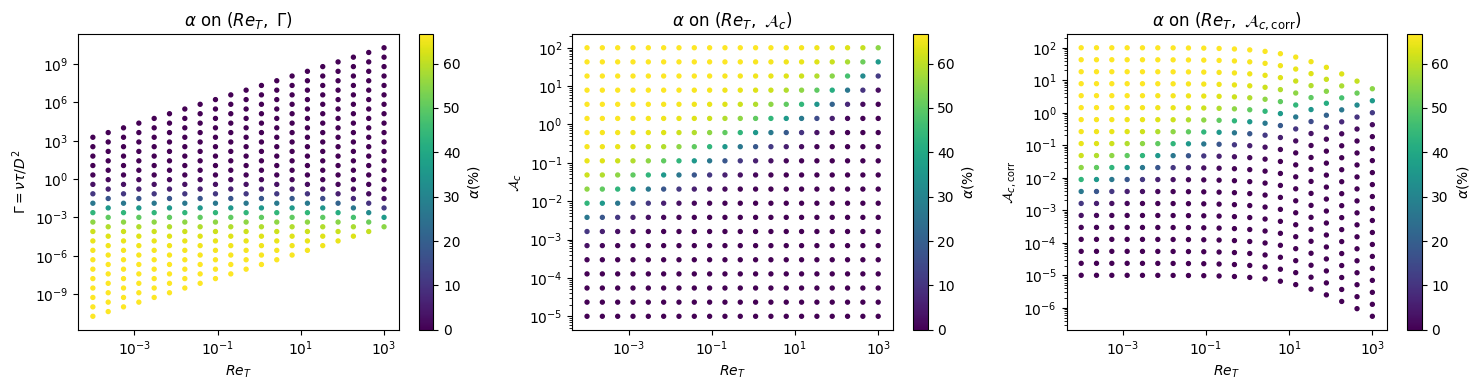

In [7]:
Re_T  = np.array([r['Re_T']   for r in results])
Gamma = np.array([r['Gamma']  for r in results])
Ac    = np.array([r['Ac']     for r in results])
Ac_c  = np.array([r['Ac_corr'] for r in results])
alpha   = np.array([r['alpha_p']  for r in results])

def phase_scatter(ax, x, y, c, xlabel, ylabel, title):
    sc = ax.scatter(x, y, c=c, cmap='viridis', s=8, vmin=0, vmax=np.percentile(c, 95))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, label=r'$\alpha (\%)$')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

phase_scatter(axes[0], Re_T, Gamma, alpha,
              r'$Re_T$', r'$\Gamma = \nu\tau/D^2$',
              r'$\alpha$ on $(Re_T,\ \Gamma)$')

phase_scatter(axes[1], Re_T, Ac, alpha,
              r'$Re_T$', r'$\mathcal{A}_c$',
              r'$\alpha$ on $(Re_T,\ \mathcal{A}_c)$')

phase_scatter(axes[2], Re_T, Ac_c, alpha,
              r'$Re_T$', r'$\mathcal{A}_{c,\mathrm{corr}}$',
              r'$\alpha$ on $(Re_T,\ \mathcal{A}_{c,\mathrm{corr}})$')

plt.tight_layout()
#plt.savefig('phase_plot.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GP kernel after fit: 0.615**2 * RBF(length_scale=[1.06, 0.673]) + WhiteKernel(noise_level=0.0001)


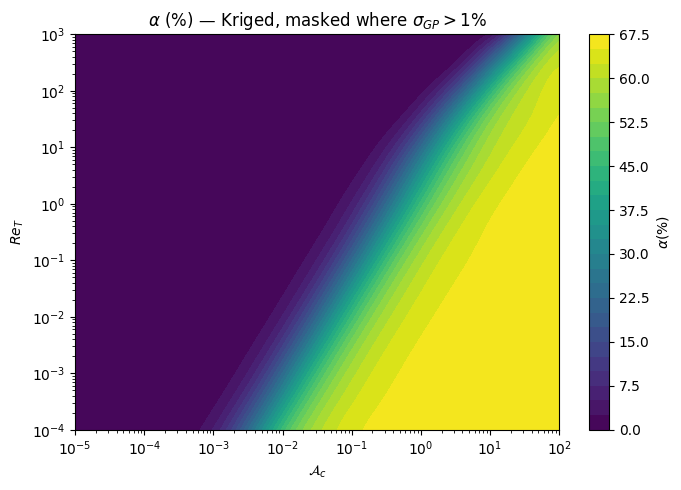

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# ── Work in log space — both axes span orders of magnitude ──────────────────
log_Re  = np.log10(Re_T)
log_Ac  = np.log10(Ac)
alpha_arr = alpha   # already a 1D numpy array

# Stack into (N_samples, 2) design matrix
X_obs = np.column_stack([log_Re, log_Ac])

# ── Gaussian process kernel ──────────────────────────────────────────────────
# ConstantKernel: overall variance
# RBF: length scale in log10 units (start at 1 decade, bounded 0.1–10)
# WhiteKernel: nugget for numerical noise in the simulated eta values
kernel = (ConstantKernel(1.0, (1e-3, 1e3))
          * RBF(length_scale=[1.0, 1.0],
                length_scale_bounds=[(0.1, 10.0), (0.1, 10.0)])
          + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 10.0)))

gp = GaussianProcessRegressor(kernel=kernel,
                               n_restarts_optimizer=10,
                               normalize_y=True)
gp.fit(X_obs, alpha_arr)
print("GP kernel after fit:", gp.kernel_)

# ── Dense prediction grid ────────────────────────────────────────────────────
n_grid = 200
log_Re_grid = np.linspace(log_Re.min(), log_Re.max(), n_grid)
log_Ac_grid = np.linspace(log_Ac.min(), log_Ac.max(), n_grid)

log_Re_mesh, log_Ac_mesh = np.meshgrid(log_Re_grid, log_Ac_grid)
X_pred = np.column_stack([log_Re_mesh.ravel(), log_Ac_mesh.ravel()])

alpha_pred, alpha_std = gp.predict(X_pred, return_std=True)
alpha_pred = alpha_pred.reshape(n_grid, n_grid)
alpha_std  = alpha_std.reshape(n_grid, n_grid)

# Clip to physically meaningful range
alpha_pred = np.clip(alpha_pred, 0, 100)

# ── Mask regions where GP uncertainty exceeds threshold ──────────────────────
uncertainty_threshold = 1.0  # % units, same as eta

alpha_plot = alpha_pred.copy()
alpha_plot[alpha_std > uncertainty_threshold] = np.nan

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

cf = ax.contourf(10**log_Ac_mesh, 10**log_Re_mesh, alpha_plot,
                 levels=30, cmap='viridis')
#ax.scatter(Re_T, Ac, c=eta, cmap='viridis', s=15,
#           edgecolors='w', linewidths=0.4,
#           vmin=np.nanmin(eta_plot), vmax=np.nanmax(eta_plot))
plt.colorbar(cf, ax=ax, label=r'$\alpha (\%)$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\mathcal{A}_c$')
ax.set_ylabel(r'$Re_T$')
ax.set_title(r'$\alpha\ (\%)$ — Kriged, masked where $\sigma_{GP} > 1\%$')

plt.tight_layout()
#plt.savefig('phase_kriged_masked.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
#vorticella
gp.predict(np.array([[np.log10(22),np.log(1.39)]]), return_std=True)

(array([29.57156707]), array([0.33587546]))

In [15]:
#A contractilis
gp.predict(np.array([[np.log10(15),np.log(1.02)]]), return_std=True)

(array([19.10793146]), array([0.33539147]))

In [16]:
#nematocyst
gp.predict(np.array([[np.log10(557),np.log(23.7)]]), return_std=True)

(array([32.44970555]), array([15.48366622]))

In [19]:
import pickle
import numpy as np

# ── Save everything needed to reconstruct the plot ───────────────────────────
kriging_result = {
    # Meshgrid axes (in log10 and linear)
    'log_Re_mesh': log_Re_mesh,
    'log_Ac_mesh': log_Ac_mesh,

    # GP predictions
    'alpha_pred': alpha_pred,      # clipped, shape (n_grid, n_grid)
    'alpha_std':  alpha_std,       # shape (n_grid, n_grid)
    'alpha_plot': alpha_plot,      # masked (nan where std > threshold), shape (n_grid, n_grid)

    # Raw sample points (for scatter overlay)
    'Re_T': Re_T,
    'Ac':   Ac,
    'alpha':  alpha,

    # Metadata
    'uncertainty_threshold': uncertainty_threshold,
    'n_grid': n_grid,
    'D_fixed': D_FIXED,
}

with open('kriging_result_DorganLoth2007.pkl', 'wb') as f:
    pickle.dump(kriging_result, f)

print("Saved kriging_result.pkl")

Saved kriging_result.pkl
